In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración básica de gráficos
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("viridis")

# Leer el archivo CSV (ajusta la ruta si es necesario)
file_path = r"/home/santiago/Escritorio/UNIVERSIDAD/TRABAJO_DE_GRADO/DATOS/processed_data.csv"
df = pd.read_csv(file_path,parse_dates=False)


# Convertir columnas de caudal a numérico (coaccionando errores a NaN)
caudal_cols = ['calamar_monthly', 'bolivar_monthly', 'manaos_monthly',
               'obidos_monthly', 'tabatinga_monthly', 'timbues_monthly']

for col in caudal_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Ver estructura
df.head()

,year,month,calamar_monthly,bolivar_monthly,manaos_monthly,obidos_monthly,tabatinga_monthly,timbues_monthly
0,2019,12,NaN,22317.741935,NaN,133473.333333,NaN,NaN
1,2019,11,NaN,34645.333333,NaN,111573.333333,NaN,NaN
2,2019,10,NaN,48297.419355,NaN,119045.161290,NaN,NaN
3,2019,9,NaN,69857.333333,NaN,189366.666667,NaN,NaN
4,2019,8,NaN,72203.225806,NaN,236867.741935,NaN,15578.267


In [35]:
def ciclo_anual_estacion(df, nombre_col, titulo, color='steelblue'):
    """
    Calcula el promedio mensual (ciclo anual) para una estación,
    usando solo los datos no nulos de su columna.
    Gráfico de línea sin marcadores.
    
    Parámetros:
    - df: DataFrame con datos
    - nombre_col: nombre de la columna de caudal
    - titulo: título para la gráfica
    - color: color de la línea (cualquier formato válido en matplotlib)
    """
    datos = df[['year', 'month', nombre_col]].copy()
    datos = datos.dropna(subset=[nombre_col])
    
    if datos.empty:
        print(f"No hay datos para {titulo}")
        return None
    
    ciclo = datos.groupby('month')[nombre_col].mean().reset_index()
    ciclo.columns = ['Mes', 'Caudal_promedio']
    
    plt.figure(figsize=(10, 5))
    plt.plot(ciclo['Mes'], ciclo['Caudal_promedio'], 
             linestyle='-', linewidth=2, color=color)
    plt.title(f'Ciclo anual de caudal - {titulo}\n(Período con datos: {datos["year"].min()} a {datos["year"].max()})')
    plt.xlabel('Mes')
    plt.ylabel('Caudal promedio (m³/s)')
    plt.xticks(range(1,13), ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic'])
    plt.grid(True, linestyle='--', alpha=0.6)
    
    print(f"\n=== Ciclo anual para {titulo} ===")
    print(ciclo.to_string(index=False))
    
    plt.show()
    return ciclo


=== Ciclo anual para Calamar ===
 Mes  Caudal_promedio
   1      7004.967742
   2      4509.429107
   3      4148.869307
   4      4975.838557
   5      6896.278286
   6      8187.345771
   7      8002.861796
   8      7420.308528
   9      7615.814677
  10      8594.451124
  11      9919.576243
  12      9904.730016


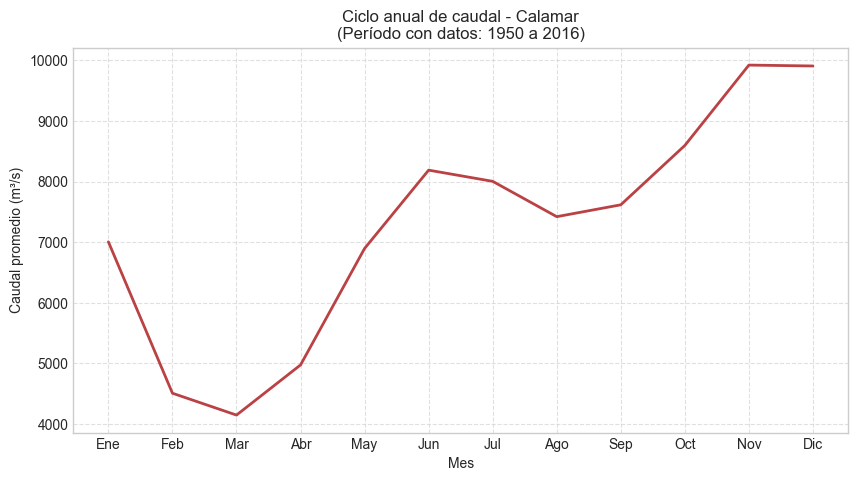

In [36]:
ciclo_calamar = ciclo_anual_estacion(df, 'calamar_monthly', 'Calamar',color='#ba4244')


=== Ciclo anual para Bolívar ===
 Mes  Caudal_promedio
   1     12740.353131
   2      7584.906331
   3      6055.017078
   4      9083.545098
   5     24194.428843
   6     40941.149020
   7     58698.908918
   8     71141.557875
   9     67217.494118
  10     49332.929791
  11     35521.515686
  12     24412.217300


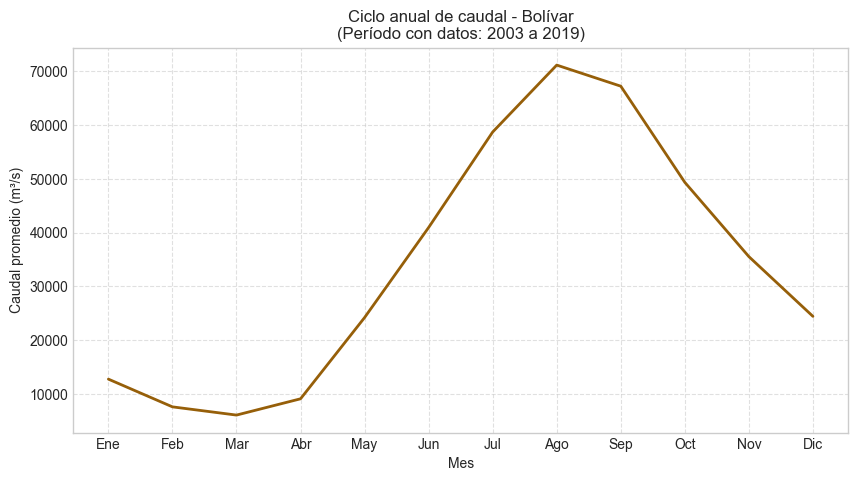

In [37]:
ciclo_bolivar = ciclo_anual_estacion(df, 'bolivar_monthly', 'Bolívar',color='#965f09')


=== Ciclo anual para Manaos ===
 Mes  Caudal_promedio
   1     92010.143369
   2     99894.117406
   3    110824.759953
   4    125734.326145
   5    136481.698432
   6    141061.122685
   7    135875.544355
   8    115274.485633
   9     84570.885180
  10     63903.177843
  11     66696.600000
  12     79541.568002


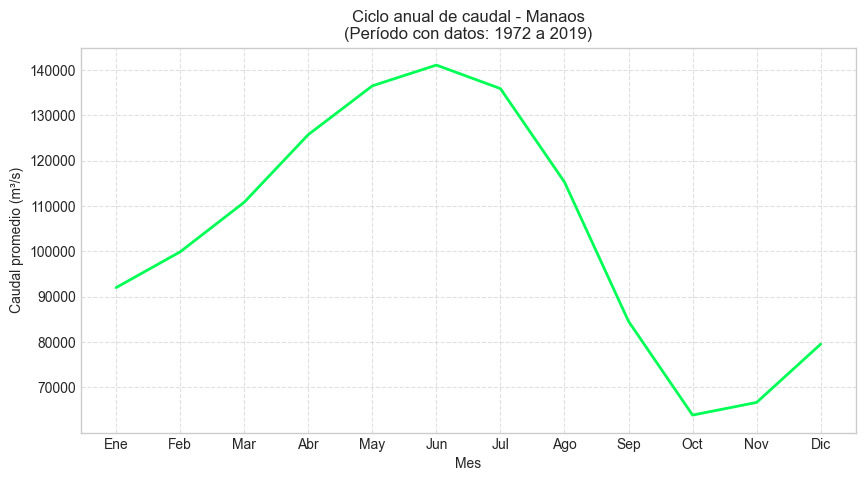

In [38]:
ciclo_manaos = ciclo_anual_estacion(df, 'manaos_monthly', 'Manaos',color='#00ff55')


=== Ciclo anual para Óbidos ===
 Mes  Caudal_promedio
   1    141591.081594
   2    165397.560629
   3    191272.642680
   4    216693.717949
   5    235180.645161
   6    237578.910256
   7    225448.697270
   8    197358.250620
   9    154419.057692
  10    113940.366005
  11    103793.038462
  12    117368.825638


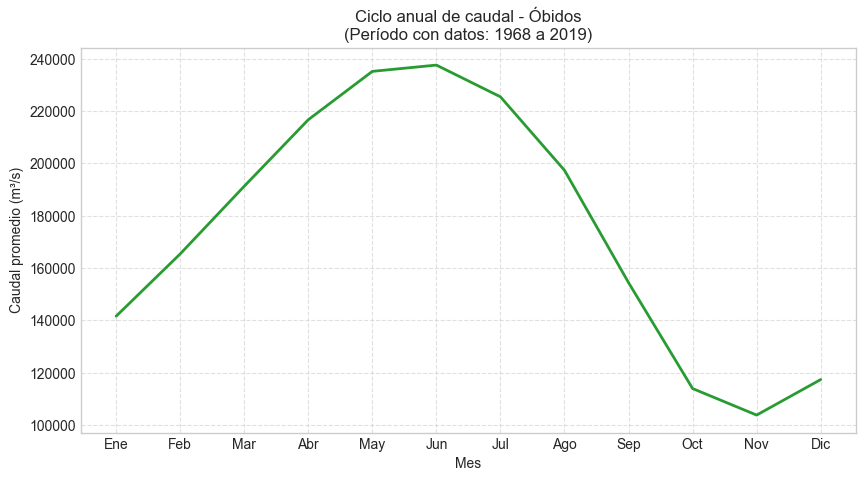

In [39]:
ciclo_obidos = ciclo_anual_estacion(df, 'obidos_monthly', 'Óbidos',color='#289c32')


=== Ciclo anual para Tabatinga ===
 Mes  Caudal_promedio
   1     38133.740192
   2     40970.579594
   3     45399.529207
   4     49549.792793
   5     50653.884853
   6     43817.424821
   7     33542.652235
   8     24245.196164
   9     20967.622909
  10     23792.972839
  11     29532.801802
  12     34665.841325


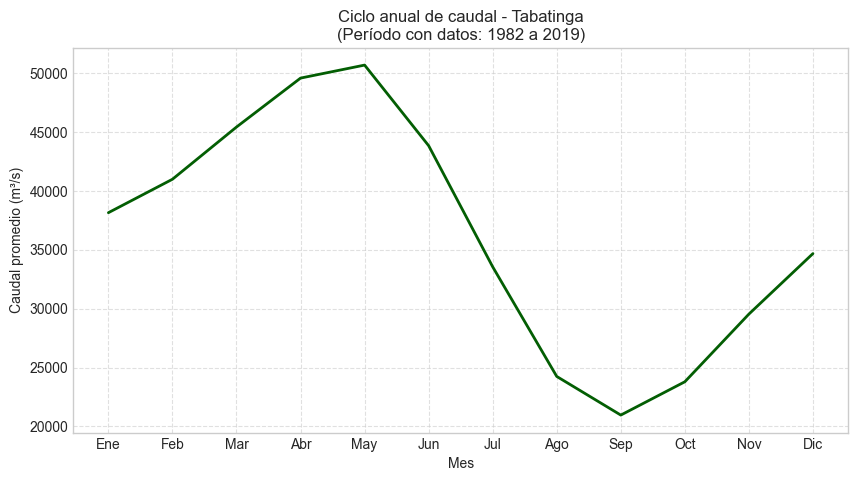

In [40]:
ciclo_tabatinga = ciclo_anual_estacion(df, 'tabatinga_monthly', 'Tabatinga',color='#035e03')


=== Ciclo anual para Timbúes ===
 Mes  Caudal_promedio
   1     15538.596446
   2     17019.561615
   3     18114.261969
   4     18304.314939
   5     17449.199816
   6     16580.724120
   7     15847.392219
   8     14171.451881
   9     12964.719152
  10     13522.911984
  11     14403.149282
  12     14622.740095


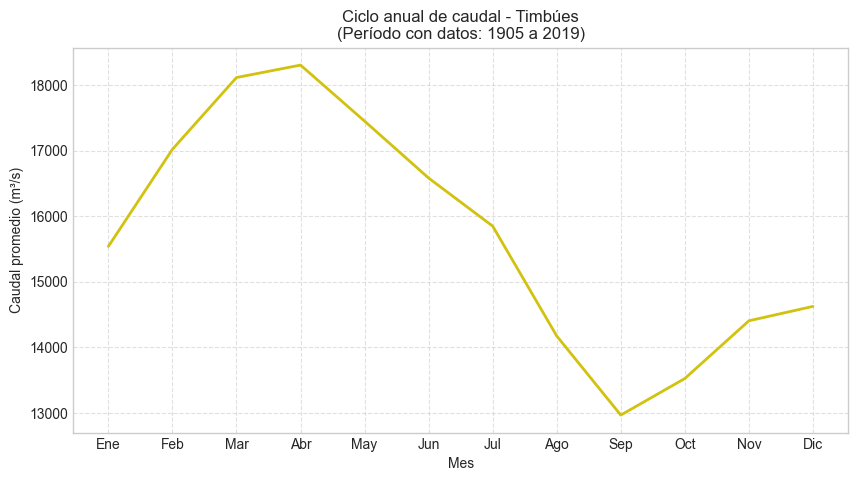

In [41]:
ciclo_timbues = ciclo_anual_estacion(df, 'timbues_monthly', 'Timbúes',color='#d2c210')

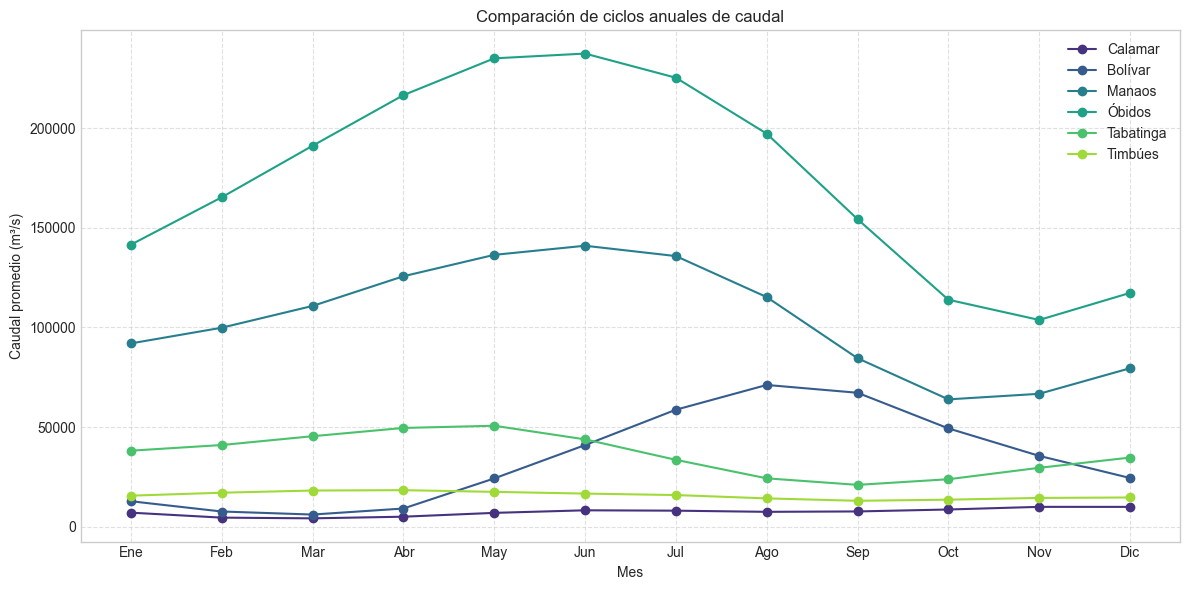

In [42]:
# Juntar todos los ciclos en un DataFrame para comparar
ciclos = {}
for col, nombre in zip(caudal_cols, ['Calamar','Bolívar','Manaos','Óbidos','Tabatinga','Timbúes']):
    datos = df[['year', 'month', col]].dropna(subset=[col])
    if not datos.empty:
        ciclo = datos.groupby('month')[col].mean()
        ciclos[nombre] = ciclo

df_ciclos = pd.DataFrame(ciclos)
df_ciclos.index = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

# Graficar
plt.figure(figsize=(12, 6))
for col in df_ciclos.columns:
    plt.plot(df_ciclos.index, df_ciclos[col], marker='o', label=col)
plt.title('Comparación de ciclos anuales de caudal')
plt.xlabel('Mes')
plt.ylabel('Caudal promedio (m³/s)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()